# GLIMPSE — Pretrained Model Inference Demo

[**Paper (arXiv:2401.00816)**](https://arxiv.org/abs/2401.00816) · [**Colab**](https://colab.research.google.com/drive/1f_YvD9WwKHN1NojIOC-HHGXAT4VgQHkz?usp=sharing)

**GLIMPSE** (Generalized Locality for Scalable and Robust CT) reconstructs a CT image from a sparse-view
sinogram by predicting **one pixel at a time** from only the sinogram data *local* to that pixel.
This locality gives it strong out-of-distribution generalization.

This notebook loads the published `glimpse.pt` checkpoint and reconstructs:
1. **In-distribution** LoDoPaB-CT test slices, and
2. **Out-of-distribution** brain images,

comparing GLIMPSE against the classical filtered-back-projection (FBP) baseline with PSNR/SSIM.

> Run from the repository root after `pip install -e .` (or `pip install -r requirements.txt`).

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

# Run from the repo root so `import glimpse` and the default paths work.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from glimpse import Config, build_model, load_checkpoint, make_dataset
from glimpse.reconstruct import make_coordinate_grid, reconstruct_image, fbp_batch
from glimpse.metrics import PSNR, SSIM

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda:0


## 1. Get the data

The demo uses the small LoDoPaB-CT **test** subset (~100 slices) and the **OOD brain** set (18 images),
hosted on SwitchDrive. The cell below downloads and extracts them into `datasets/` only if they are not
already present.

In [2]:
import subprocess, zipfile, glob

DOWNLOADS = {
    'datasets/test': 'https://drive.switch.ch/index.php/s/fWBUmtZjozwpN9W/download',
    'datasets/ood':  'https://drive.switch.ch/index.php/s/BQ8Yb8ofjutsEjV/download',
}
os.makedirs('datasets', exist_ok=True)

def ensure_dataset(target_dir, url):
    if os.path.isdir(target_dir) and glob.glob(os.path.join(target_dir, '*')):
        print(f'[ok] {target_dir} already present')
        return
    zip_path = target_dir + '.zip'
    print(f'[..] downloading {url} -> {zip_path}')
    subprocess.run(['curl', '-sS', '-L', '-o', zip_path, url], check=True)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall('datasets')
    print(f'[ok] extracted into datasets/')

for target, url in DOWNLOADS.items():
    ensure_dataset(target, url)

print('test  :', len(glob.glob('datasets/test/*')), 'files')
print('ood   :', len(glob.glob('datasets/ood/*')), 'files')

[ok] datasets/test already present
[ok] datasets/ood already present
test  : 111 files
ood   : 18 files


## 2. Load the pretrained model

We build the model from `configs/lodopab.yaml` (ODL geometry — what the published `glimpse.pt` was trained
with) and load the checkpoint. `load_checkpoint` reports any missing/unexpected parameter keys.

In [3]:
config = Config.from_yaml('configs/lodopab.yaml')
true_angles, init_angles = config.resolve_angles()

model = build_model(config, init_angles).to(device)
missing, unexpected = load_checkpoint(model, 'glimpse.pt', map_location=device)
model.eval()
print('geometry        :', config.geometry)
print('missing keys    :', missing)
print('unexpected keys :', unexpected)

geometry        : odl
missing keys    : []
unexpected keys : []


## 3. Reconstruct in-distribution test slices

`make_dataset(..., network='odl')` returns the raw images; the ODL parallel-beam operator
(`glimpse.operators.build_operator`) renders the sparse-view sinograms and the FBP baseline on the
GPU — the exact forward model `glimpse.pt` was trained with. We then reconstruct each full image by
evaluating the model over every pixel coordinate via `reconstruct_image`.

In [4]:
from glimpse.operators import build_operator

# ODL parallel-beam operator at the true acquisition angles (GPU, astra_cuda).
operator = build_operator(config, np.deg2rad(true_angles))

def reconstruct_n(directory, n=4):
    ds = make_dataset(directory, config, true_angles, init_angles, network='odl')
    _, volumes = zip(*[ds[i] for i in range(min(n, len(ds)))])
    volume = torch.as_tensor(np.stack(volumes), dtype=torch.float32).to(device)
    gt = volume.cpu().numpy()
    sino = operator.project(volume)              # (n, n_angles, n_det)
    fbp = operator.fbp(sino).cpu().numpy()       # analytic baseline
    coords = make_coordinate_grid(config.image_size).unsqueeze(0).expand(len(volumes), -1, -1).to(device)
    recon = reconstruct_image(sino, coords, 1, model, chunk_size=1024)
    recon = recon.reshape(len(volumes), config.image_size, config.image_size)
    return gt, fbp, recon

gt, fbp, recon = reconstruct_n('datasets/test', n=4)
print('FBP     PSNR %.2f dB | SSIM %.3f' % (PSNR(gt, fbp), SSIM(gt, fbp)))
print('GLIMPSE PSNR %.2f dB | SSIM %.3f' % (PSNR(gt, recon), SSIM(gt, recon)))

FBP     PSNR 30.65 dB | SSIM 0.806
GLIMPSE PSNR 38.09 dB | SSIM 0.946


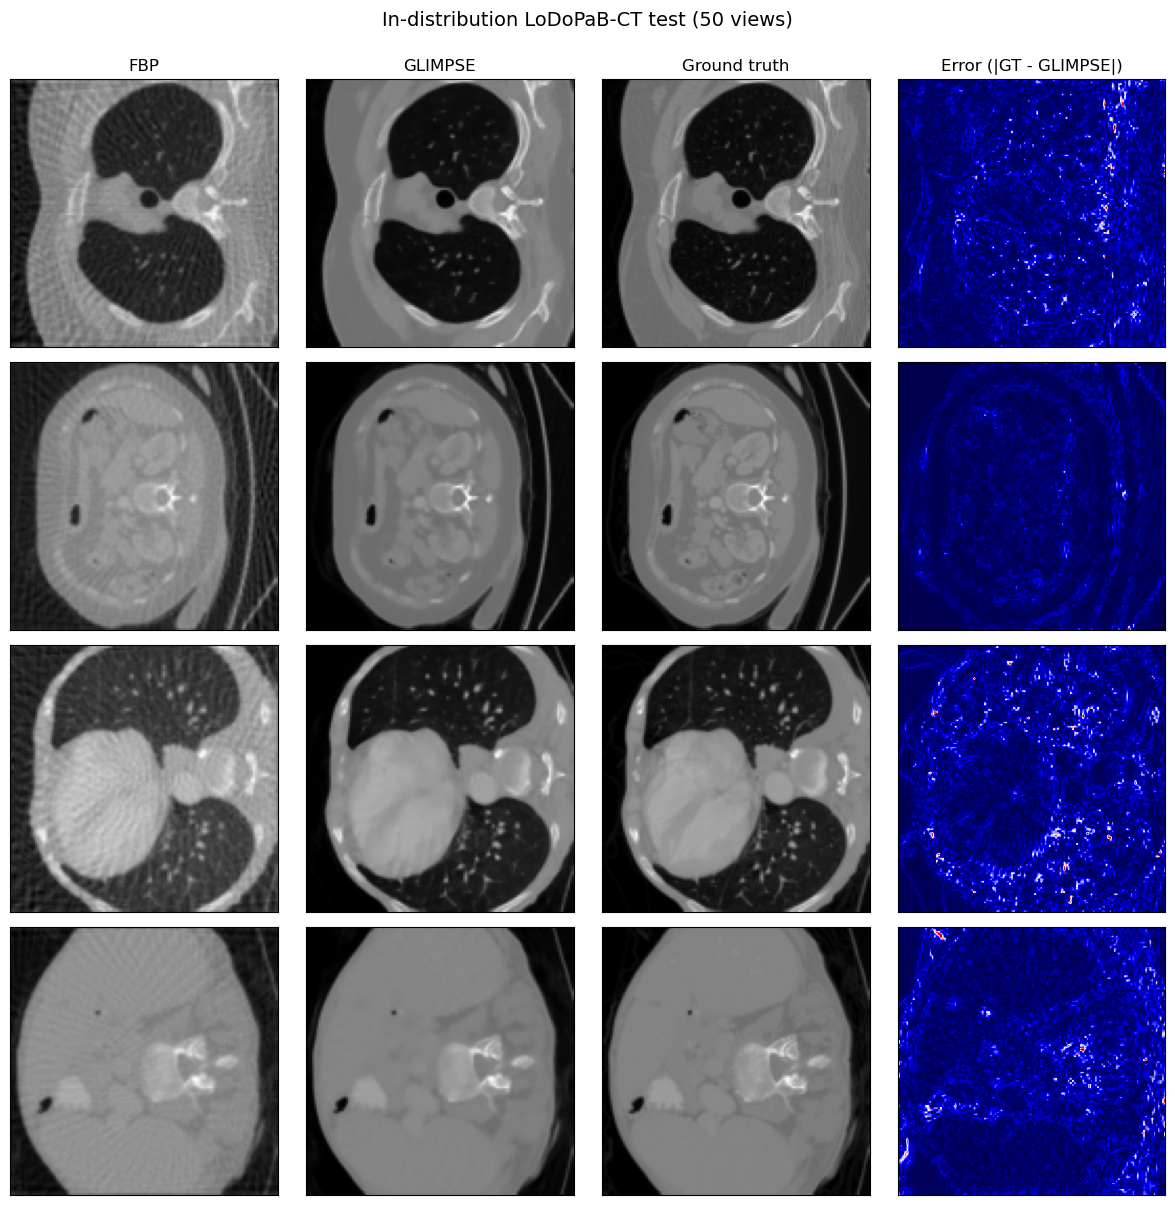

In [5]:
def show_comparison(gt, fbp, recon, title=''):
    n = len(gt)
    fig, ax = plt.subplots(n, 4, figsize=(12, 3 * n))
    ax = np.atleast_2d(ax)
    cols = ['FBP', 'GLIMPSE', 'Ground truth', 'Error (|GT - GLIMPSE|)']
    for i in range(n):
        ax[i, 0].imshow(fbp[i], cmap='gray')
        ax[i, 1].imshow(recon[i], cmap='gray')
        ax[i, 2].imshow(gt[i], cmap='gray')
        ax[i, 3].imshow(np.abs(gt[i] - recon[i]), cmap='seismic')
        for j, c in enumerate(cols):
            ax[i, j].set_xticks([]); ax[i, j].set_yticks([])
            if i == 0:
                ax[i, j].set_title(c)
    if title:
        fig.suptitle(title, y=1.0, fontsize=14)
    plt.tight_layout(); plt.show()

show_comparison(gt, fbp, recon, title='In-distribution LoDoPaB-CT test (50 views)')

## 4. Out-of-distribution generalization (brain images)

The same model — without any retraining — reconstructs brain images it never saw during training,
illustrating the benefit of GLIMPSE's local, coordinate-based design.

OOD FBP     PSNR 27.67 dB | SSIM 0.550
OOD GLIMPSE PSNR 33.30 dB | SSIM 0.902


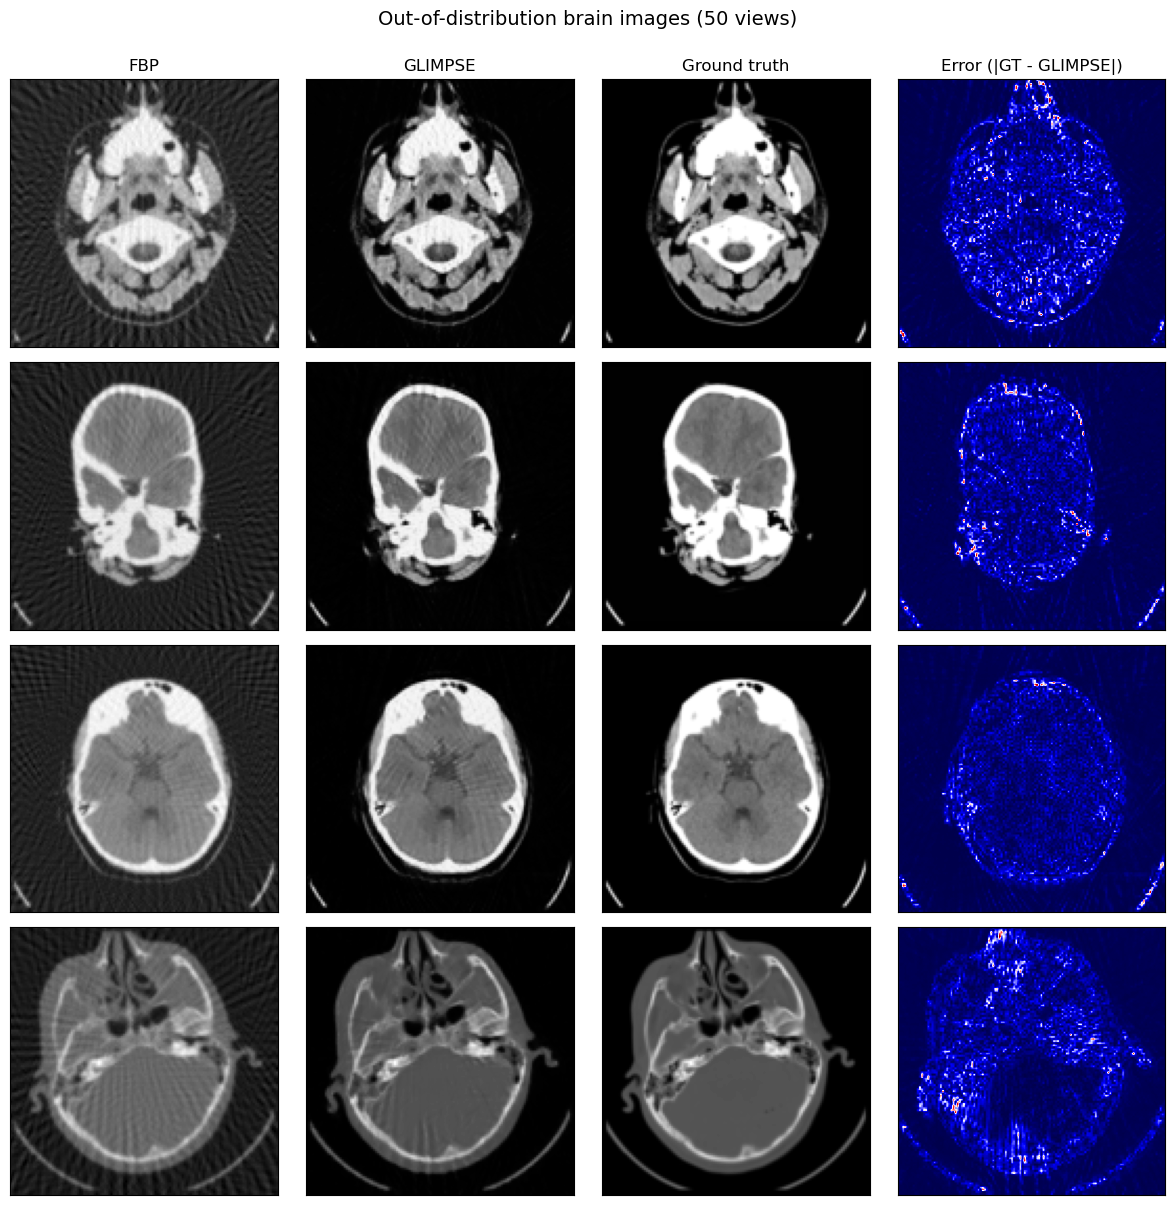

In [6]:
gt_o, fbp_o, recon_o = reconstruct_n('datasets/ood', n=4)
print('OOD FBP     PSNR %.2f dB | SSIM %.3f' % (PSNR(gt_o, fbp_o), SSIM(gt_o, fbp_o)))
print('OOD GLIMPSE PSNR %.2f dB | SSIM %.3f' % (PSNR(gt_o, recon_o), SSIM(gt_o, recon_o)))
show_comparison(gt_o, fbp_o, recon_o, title='Out-of-distribution brain images (50 views)')

## 5. Try other settings

Everything is driven by a `Config`. A few things to experiment with:

- **More / fewer views:** generate a dataset with a different `n_angles` and retrain (`python train.py --config configs/lodopab.yaml --n-angles 60`).
- **Uncalibrated geometry:** `configs/uncalibrated.yaml` tells the model jittered angles and relies on the learnable sensor geometry to recover them.
- **Learned vs fixed filter / patch:** toggle `learnable_filter`, `learn_patch`, `patch_shape` in the config.

See the [README](../README.md) for training and dataset details.